In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
"""Script de entrenamiento para modelos de clasificación PET."""

import os
import sys

import torch
from matplotlib import pyplot as plt

# Importar módulos propios
from data.dataset import get_test_data_loader
from utils.config_utils import load_config

# Añadir directorios al path
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))

In [8]:
config_path = "configs/resnet18_2d_adni_cnad_multi_eval.yaml"

# Cargar configuración
config = load_config(config_path)

# Configurar dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Usando dispositivo: {device}")

# Obtener parámetros del modelo
model_config = config.get("model", {})
# model_name = model_config.get("name", "resnet18").lower()
# dimension = model_config.get("dimension", "2d").lower()

# Crear directorio para el experimento
# exp_base_dir = config.get("experiment", {}).get("base_dir", "./experiments")
# dataset_name = config.get("data", {}).get("dataset_name", "ADNI")
classes = config.get("data", {}).get("classes", "CN_AD")
# exp_name = config.get("experiment", {}).get("name", None)

# Crear modelo
num_classes = len(classes.split("_"))
model_config["num_classes"] = num_classes

# Obtener data loaders
# train_loader, val_loader, test_loader = get_data_loaders(config)

Usando dispositivo: cuda


In [13]:
adni_test_loader = get_test_data_loader(config, "data")

📊 Creando test loader para: ['CN', 'AD'] (2 clases)
📊 Dataset: ADNI
CSV cargado. Filas: 112
2D
Modo: test, Selección de cortes: middle
Clase(s): 2 (CN, AD)
Output size: [224, 224], Canales: 3
Usando umbralizado de Otsu para máscara cerebral
Usando columna 'Subject' para identificar sujetos
Usando columna 'Group' para diagnósticos
Valores únicos en 'Group': ['MCI', 'CN', 'AD']


Cargando dataset:   0%|          | 0/112 [00:00<?, ?it/s]

Cargando imagen: ./data/NIFTIs/Archivo/converted_niftis/012_S_5121.nii.gz
Dimensiones de la imagen: (128, 128, 35, 6)
Header de la imagen: <class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'')
dim_info        : 0
dim             : [  4 128 128  35   6   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [  1.     2.     2.     4.25 300.     1.     1.     1.  ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'FreeSurfer Feb  5 2025')
aux_file        : np.by

Cargando dataset:   4%|▍         | 5/112 [00:00<00:04, 22.82it/s]

Imagen procesada final: torch.Size([3, 224, 224])


Cargando dataset: 100%|██████████| 112/112 [00:31<00:00,  3.53it/s]

Total de muestras cargadas: 57 de 57 sujetos

Distribución de clases:
  - CN: 57 muestras (100.0%)
  - AD: 57 muestras (100.0%)
✅ Test loader creado - 57 muestras


In [ ]:
adni_test_loader = get_test_data_loader(config, "data")
eval_config = config.copy()
fleni100_test_loader = get_test_data_loader(eval_config, "data2")
fleni600_test_loader = get_test_data_loader(eval_config, "data3")

📊 Creando test loader para: ['CN', 'AD'] (2 clases)
📊 Dataset: fleni100
CSV cargado. Filas: 123
2D
Modo: test, Selección de cortes: middle
Clase(s): 2 (CN, AD)
Output size: [224, 224], Canales: 3
Usando umbralizado de Otsu para máscara cerebral
Usando columna 'Subject' para identificar sujetos
Usando columna 'Group' para diagnósticos
Valores únicos en 'Group': ['AD', 'CN']


Cargando dataset:   2%|▏         | 2/123 [00:00<00:09, 12.62it/s]

Cargando imagen: ./data/NIFTIs/fleni100/converted_niftis/b87479c8-641ec909-8b8effc1-9b58a18a-573f8414.nii.gz
Dimensiones de la imagen: (128, 128, 47)
Header de la imagen: <class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'')
dim_info        : 0
dim             : [  3 128 128  47   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [-1.    2.    2.    3.27  1.    1.    1.    1.  ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 2
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'')
aux_file        : np.b

Cargando dataset: 100%|██████████| 123/123 [00:10<00:00, 12.15it/s]


Total de muestras cargadas: 123 de 123 sujetos

Distribución de clases:
  - CN: 123 muestras (100.0%)
  - AD: 123 muestras (100.0%)
✅ Test loader creado - 123 muestras
📊 Creando test loader para: ['CN', 'AD'] (2 clases)
📊 Dataset: fleni600
CSV cargado. Filas: 638
2D
Modo: test, Selección de cortes: middle
Clase(s): 2 (CN, AD)
Output size: [224, 224], Canales: 3
Usando umbralizado de Otsu para máscara cerebral
Usando columna 'Subject' para identificar sujetos
Usando columna 'Group' para diagnósticos
Valores únicos en 'Group': ['AD', 'CN']


...

Error al procesar imagen ./data/NIFTIs/fleni600/converted_niftis/subject_721_pet.nii.gz: Compressed file ended before the end-of-stream marker was reached


Cargando dataset:  36%|███▌      | 231/638 [00:17<00:30, 13.20it/s]Traceback (most recent call last):
  File "/mnt/disk2/PET_2025/data/dataset.py", line 429, in _load_dataset
    nifti = nli.load_img(img_path)  # Usar nilearn para cargar imágenes NIfTI
            ^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ipardo/.conda/envs/pet/lib/python3.12/site-packages/nilearn/image/image.py", line 1693, in load_img
    return check_niimg(img, wildcards=wildcards, dtype=dtype)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ipardo/.conda/envs/pet/lib/python3.12/site-packages/nilearn/_utils/niimg_conversions.py", line 353, in check_niimg
    niimg = load_niimg(niimg, dtype=dtype)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ipardo/.conda/envs/pet/lib/python3.12/site-packages/nilearn/_utils/niimg.py", line 127, in load_niimg
    img_data = _get_data(niimg)
               ^^^^^^^^^^^^^^^^
  File "/home/ipardo/.conda/envs/pet/lib/python3.12/site-packages/nilearn/_util

Error al procesar imagen ./data/NIFTIs/fleni600/converted_niftis/subject_260_pet.nii.gz: Compressed file ended before the end-of-stream marker was reached


Cargando dataset: 100%|██████████| 638/638 [00:48<00:00, 13.23it/s]

Total de muestras cargadas: 636 de 636 sujetos

Distribución de clases:
  - CN: 636 muestras (100.0%)
  - AD: 636 muestras (100.0%)
✅ Test loader creado - 636 muestras


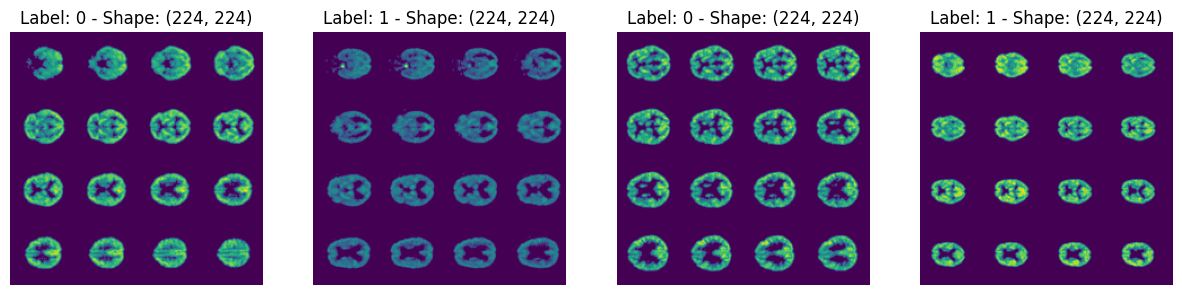

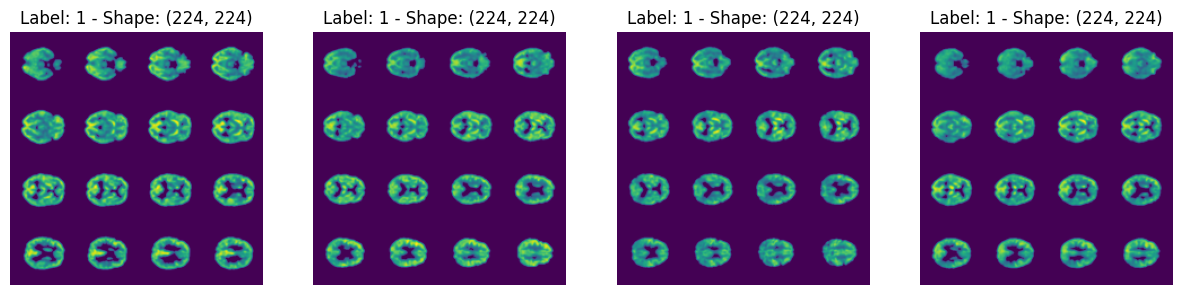

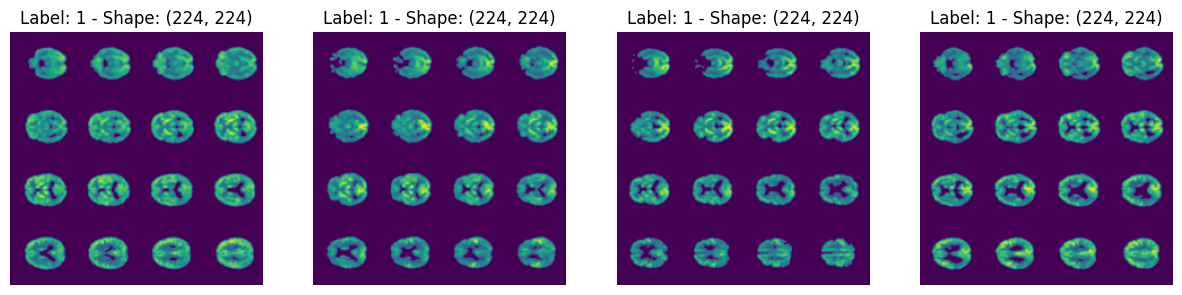

In [14]:
# Plot images from the training set
def plot_images(data_loader, num_images=4):
    images = []
    labels = []

    # Collect images and labels from the data loader
    for i, (image, label) in enumerate(data_loader):
        if i >= num_images:
            break
        images.append(image)
        labels.append(label)
    images = torch.stack(images)
    labels = torch.stack(labels)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        img = images[i].squeeze().cpu().numpy()
        # normalize the image to [0, 1] range for better visualization
        img = (img - img.min()) / (img.max() - img.min())
        img = img * 255
        if img.ndim == 4:
            img = img[0]
        img = img[0]

        axes[i].imshow(img, cmap="viridis")
        axes[i].set_title(f"Label: {torch.argmax(labels[i]).item()} - Shape: {img.shape}")
        axes[i].axis("off")
    plt.show()


# Plot images from the training set
plot_images(adni_test_loader, num_images=4)
plot_images(fleni100_test_loader, num_images=4)
plot_images(fleni600_test_loader, num_images=4)